In [1]:
import sys 
sys.path.append('../')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [3]:
from src.connect import run_query,save_df_to_db

In [4]:
query = f"""

SELECT * 
FROM walmart AS m
"""

data = run_query(query)

In [5]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [6]:
print("INFORMATIONS GÉNÉRALES")
print("=" * 50)
print(f"Shape des données: {data.shape}")
print(f"Période: {data['Date'].min()} à {data['Date'].max()}")
print(f"Nombre de magasins: {data['Store'].nunique()}")
print(f"Nombre de semaines: {len(data['Date'].unique())}")

INFORMATIONS GÉNÉRALES
Shape des données: (6435, 8)
Période: 01-04-2011 à 31-12-2010
Nombre de magasins: 45
Nombre de semaines: 143


In [7]:
import pandas as pd
data["Date"] = pd.to_datetime(data["Date"],format='%d-%m-%Y')

In [8]:
data = data.sort_values(["Store","Date"],ascending=True)

In [9]:
data.isnull().mean()

Store           0.0
Date            0.0
Weekly_Sales    0.0
Holiday_Flag    0.0
Temperature     0.0
Fuel_Price      0.0
CPI             0.0
Unemployment    0.0
dtype: float64

In [10]:
data["Month"] = data["Date"].dt.month
data["Year"] = data["Date"].dt.year
data["Day"] = data["Date"].dt.day

In [11]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,5


In [12]:
def extract_season(month):
    if month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    elif  month in [9,10,11]:
        return "Autumn"
    else : 
        return "Winter"
    
data["Season"] = data['Month'].apply(extract_season)

In [13]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Day,Season
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,5,Winter
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,12,Winter
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,19,Winter
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,26,Winter
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,5,Spring


In [14]:
date_col = "Date"
data["day_of_week"] = data['Date'].dt.dayofweek
data['week_of_year'] = data[date_col].dt.isocalendar().week
data['quarter'] = data[date_col].dt.quarter
data['is_month_start'] = data[date_col].dt.is_month_start.astype(int)
data['is_month_end'] = data[date_col].dt.is_month_end.astype(int)
data['is_quarter_start'] = data[date_col].dt.is_quarter_start.astype(int)
data['is_quarter_end'] = data[date_col].dt.is_quarter_end.astype(int)


In [15]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Day,Season,day_of_week,week_of_year,quarter,is_month_start,is_month_end,is_quarter_start,is_quarter_end
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,5,Winter,4,5,1,0,0,0,0
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,12,Winter,4,6,1,0,0,0,0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,19,Winter,4,7,1,0,0,0,0
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,26,Winter,4,8,1,0,0,0,0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,5,Spring,4,9,1,0,0,0,0


In [16]:
print("les stores de walmart:",data["Store"].unique())
print("nombre de ces stores :",len(data["Store"].unique()))

les stores de walmart: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]
nombre de ces stores : 45


In [17]:
def create_rolling_features(df, target_col='Weekly_Sales', store_col='Store', 
                            windows=[2, 4]):
    df = df.copy()
    df = df.sort_values([store_col, 'Date'])
    
    for window in windows:
        df[f'{target_col}_rolling_mean_{window}'] = df.groupby(store_col)[target_col].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        
        df[f'{target_col}_rolling_std_{window}'] = df.groupby(store_col)[target_col].transform(
            lambda x: x.rolling(window=window, min_periods=1).std()
        )
        
    return df

data = create_rolling_features(df=data)

In [18]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,...,week_of_year,quarter,is_month_start,is_month_end,is_quarter_start,is_quarter_end,Weekly_Sales_rolling_mean_2,Weekly_Sales_rolling_std_2,Weekly_Sales_rolling_mean_4,Weekly_Sales_rolling_std_4
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,...,5,1,0,0,0,0,1643690.900,NaN,1.643691e+06,NaN
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,...,6,1,0,0,0,0,1642824.170,1225.741321,1.642824e+06,1225.741321
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,...,7,1,0,0,0,0,1626962.805,21205.616180,1.632539e+06,17835.791719
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,...,8,1,0,0,0,0,1510847.880,143005.685549,1.576836e+06,112353.415114
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,...,9,1,0,0,0,0,1482267.135,102586.408347,1.554615e+06,103135.002548


In [19]:
def create_growth_features(df, target_col='Weekly_Sales', store_col='Store'):
    df = df.copy()
    df = df.sort_values([store_col, 'Date'])
    
    df[f'{target_col}_pct_change'] = df.groupby(store_col)[target_col].pct_change()
    
    df[f'{target_col}_diff'] = df.groupby(store_col)[target_col].diff()
    
    return df

data = create_growth_features(data)

In [20]:
print(data['Temperature_C'].dtype)
print(data['Season_encode'].dtype)
print(data['Season_encode'].unique())
print(data.columns)
print(data['Season'].unique())  
print(data['Holiday_Flag'].dtype)
print(data['Holiday_Flag'].unique())


KeyError: 'Temperature_C'

In [22]:
events = {
    'Super_Bowl': ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'],
    'Labour_Day': ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'],
    'Thanksgiving': ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'],
    'Christmas': ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']
}

for key in events:
    events[key] = pd.to_datetime(events[key])

def is_near_event(date, event_dates, window=7):
    return any(abs((date - event_date).days) <= window for event_date in event_dates)

for event_name, event_dates in events.items():
    data[event_name+'_flag'] = data['Date'].apply(lambda x: 1 if is_near_event(x, event_dates) else 0)

In [23]:
data["Temperature_C"] = (data["Temperature"] - 32) * 5/9

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data["Season_encode"] = le.fit_transform(data['Season'])

data["Season_encode"] = data["Season_encode"].astype('float64')
data["Holiday_Flag"] = data["Holiday_Flag"].astype('float64')
def create_interaction_features(df):

    df = df.copy()
    
    df['fuel_price_x_unemployment'] = df['Fuel_Price'] * df['Unemployment']
    df['cpi_x_unemployment'] = df['CPI'] * df['Unemployment']
    df['temp_x_season'] = df['Temperature_C'] * df['Season_encode']
    
    df['holiday_x_fuel_price'] = df['Holiday_Flag'] * df['Fuel_Price']
    df['holiday_x_temperature'] = df['Holiday_Flag'] * df['Temperature_C']
    
    holiday_cols = ['Super_Bowl_flag', 'Labour_Day_flag', 'Thanksgiving_flag', 'Christmas_flag']
    df['total_holidays'] = df[holiday_cols].sum(axis=1)
    
    return df

data = create_interaction_features(data)

In [24]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,...,Super_Bowl_flag,Labour_Day_flag,Thanksgiving_flag,Christmas_flag,fuel_price_x_unemployment,cpi_x_unemployment,temp_x_season,holiday_x_fuel_price,holiday_x_temperature,total_holidays
0,1,2010-02-05,1643690.90,0.0,42.31,2.572,211.096358,8.106,2,2010,...,1,0,0,0,20.848632,1711.147080,17.183333,0.000,0.000000,1
1,1,2010-02-12,1641957.44,1.0,38.51,2.548,211.242170,8.106,2,2010,...,1,0,0,0,20.654088,1712.329028,10.850000,2.548,3.616667,1
2,1,2010-02-19,1611968.17,0.0,39.93,2.514,211.289143,8.106,2,2010,...,1,0,0,0,20.378484,1712.709792,13.216667,0.000,0.000000,1
3,1,2010-02-26,1409727.59,0.0,46.63,2.561,211.319643,8.106,2,2010,...,0,0,0,0,20.759466,1712.957025,24.383333,0.000,0.000000,0
4,1,2010-03-05,1554806.68,0.0,46.50,2.625,211.350143,8.106,3,2010,...,0,0,0,0,21.278250,1713.204258,8.055556,0.000,0.000000,0


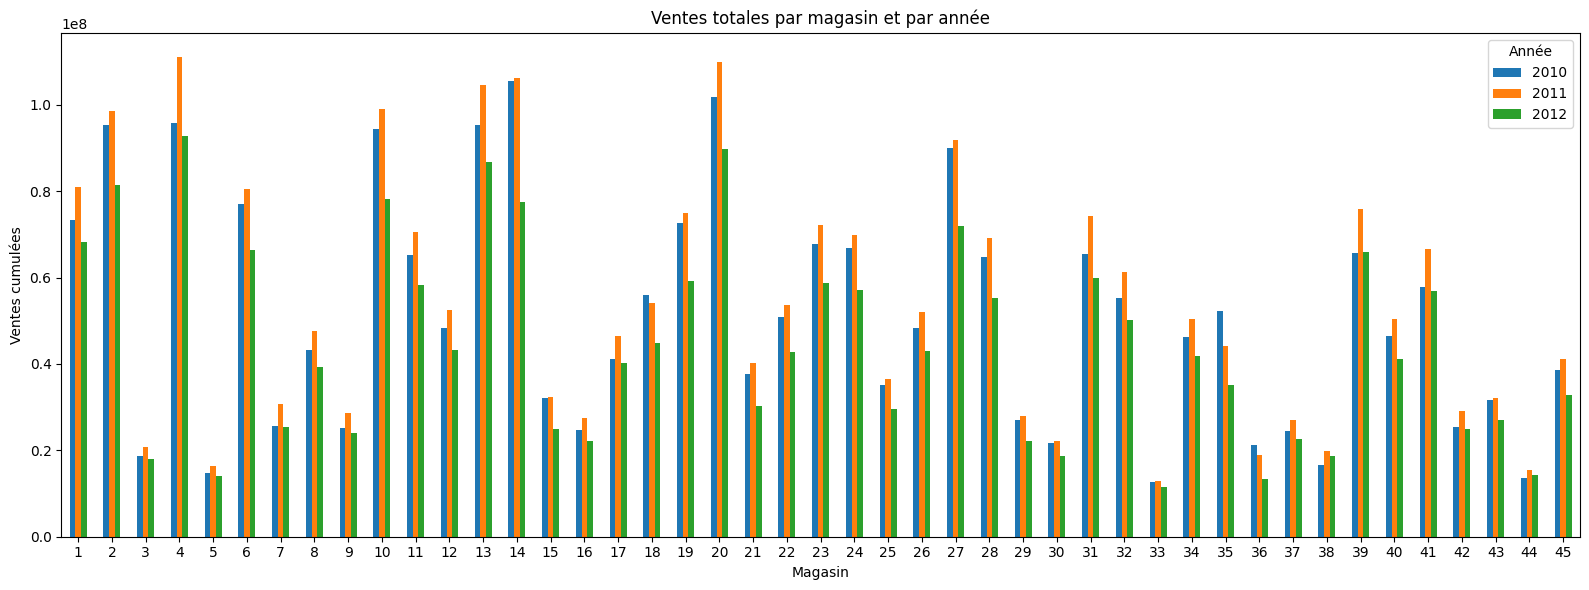

In [25]:
store_year_sales = data.groupby(["Store", "Year"])["Weekly_Sales"].sum().unstack()
store_year_sales.plot(kind="bar", figsize=(16, 6))
plt.title("Ventes totales par magasin et par année")
plt.xlabel("Magasin")
plt.ylabel("Ventes cumulées")
plt.legend(title="Année")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

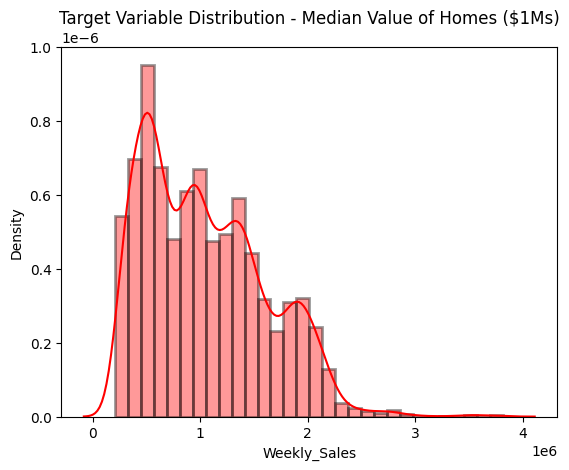

In [26]:
import seaborn as sns 

sns.distplot(data['Weekly_Sales'],color='r',hist_kws=dict(edgecolor="black", linewidth=2), bins=30)
plt.title('Target Variable Distribution - Median Value of Homes ($1Ms)')
plt.show()

In [27]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,...,Super_Bowl_flag,Labour_Day_flag,Thanksgiving_flag,Christmas_flag,fuel_price_x_unemployment,cpi_x_unemployment,temp_x_season,holiday_x_fuel_price,holiday_x_temperature,total_holidays
0,1,2010-02-05,1643690.90,0.0,42.31,2.572,211.096358,8.106,2,2010,...,1,0,0,0,20.848632,1711.147080,17.183333,0.000,0.000000,1
1,1,2010-02-12,1641957.44,1.0,38.51,2.548,211.242170,8.106,2,2010,...,1,0,0,0,20.654088,1712.329028,10.850000,2.548,3.616667,1
2,1,2010-02-19,1611968.17,0.0,39.93,2.514,211.289143,8.106,2,2010,...,1,0,0,0,20.378484,1712.709792,13.216667,0.000,0.000000,1
3,1,2010-02-26,1409727.59,0.0,46.63,2.561,211.319643,8.106,2,2010,...,0,0,0,0,20.759466,1712.957025,24.383333,0.000,0.000000,0
4,1,2010-03-05,1554806.68,0.0,46.50,2.625,211.350143,8.106,3,2010,...,0,0,0,0,21.278250,1713.204258,8.055556,0.000,0.000000,0


In [28]:
data.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year', 'Day', 'Season',
       'day_of_week', 'week_of_year', 'quarter', 'is_month_start',
       'is_month_end', 'is_quarter_start', 'is_quarter_end',
       'Weekly_Sales_rolling_mean_2', 'Weekly_Sales_rolling_std_2',
       'Weekly_Sales_rolling_mean_4', 'Weekly_Sales_rolling_std_4',
       'Weekly_Sales_pct_change', 'Weekly_Sales_diff', 'Temperature_C',
       'Season_encode', 'Super_Bowl_flag', 'Labour_Day_flag',
       'Thanksgiving_flag', 'Christmas_flag', 'fuel_price_x_unemployment',
       'cpi_x_unemployment', 'temp_x_season', 'holiday_x_fuel_price',
       'holiday_x_temperature', 'total_holidays'],
      dtype='object')

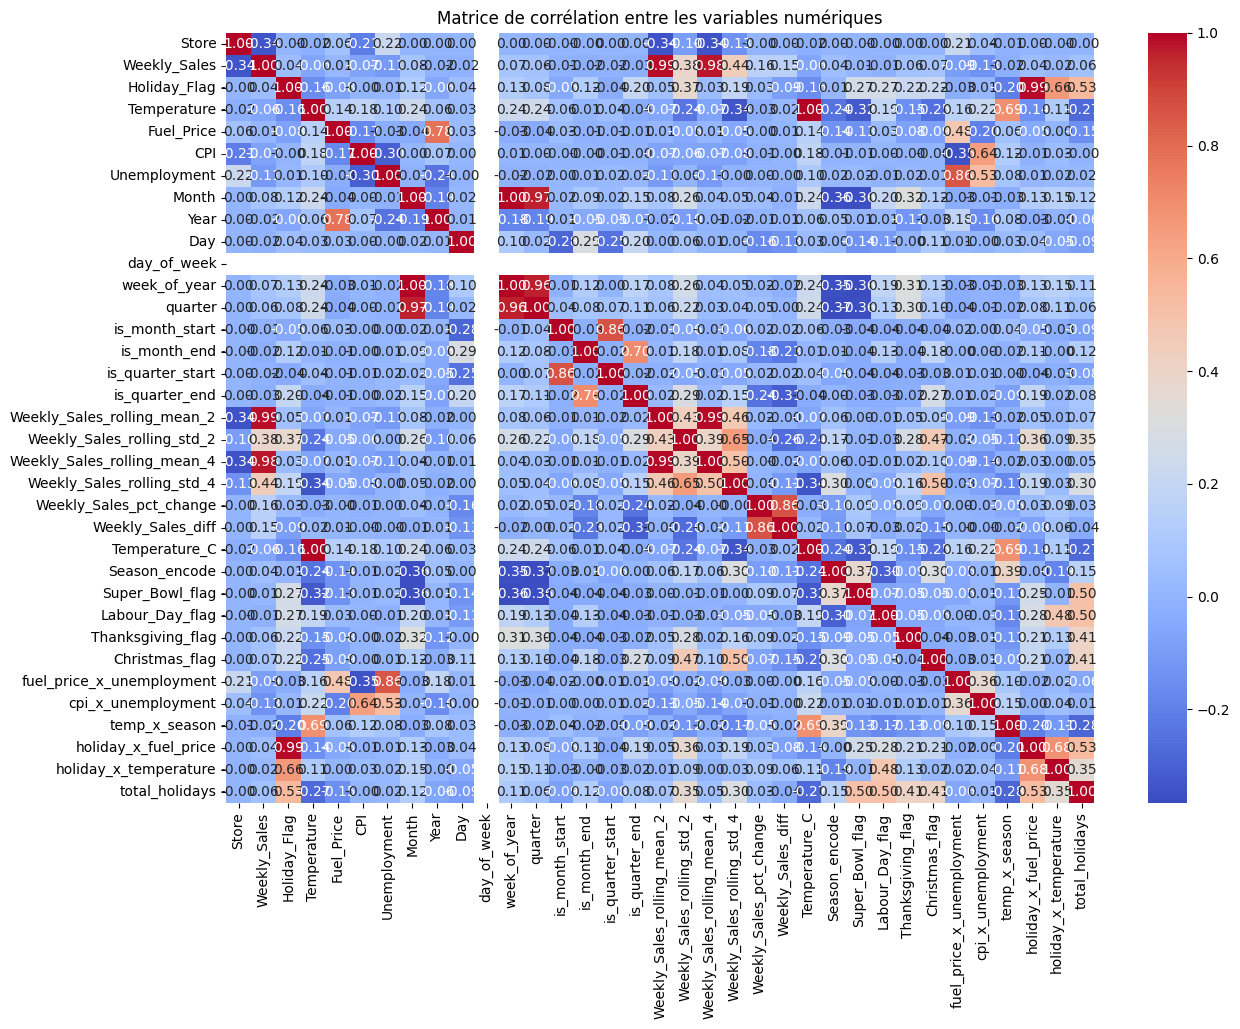

In [29]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Matrice de corrélation entre les variables numériques")
plt.show()

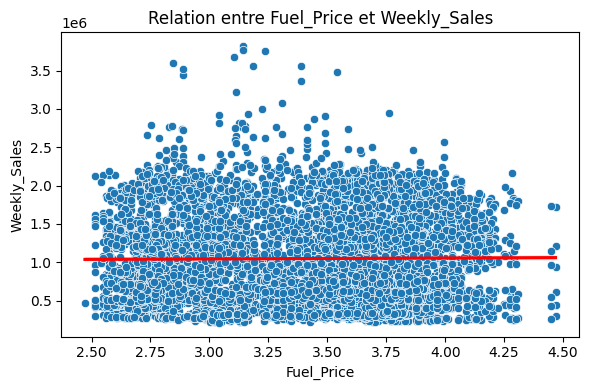

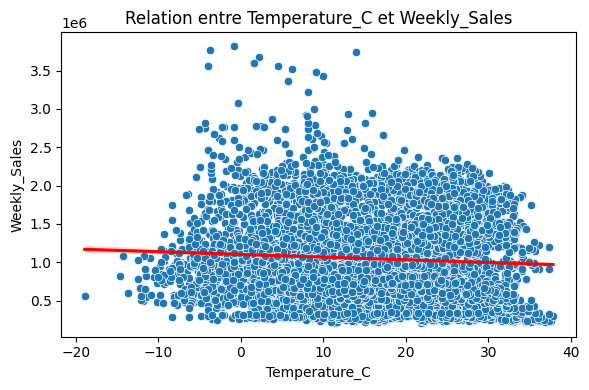

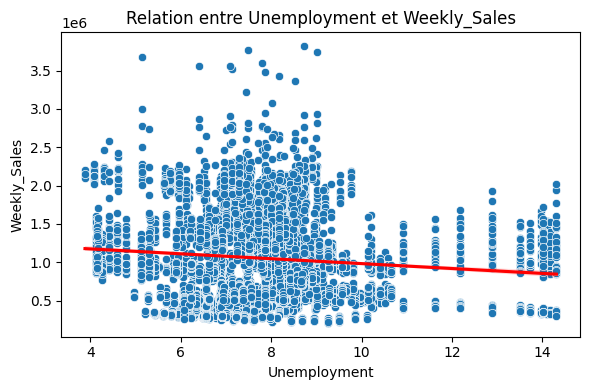

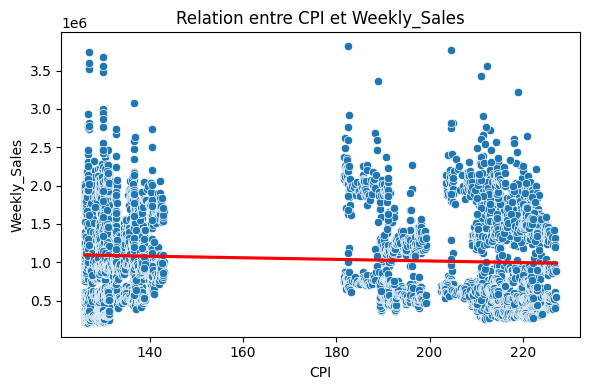

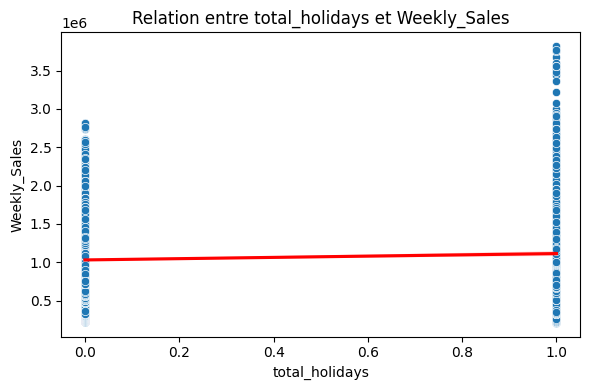

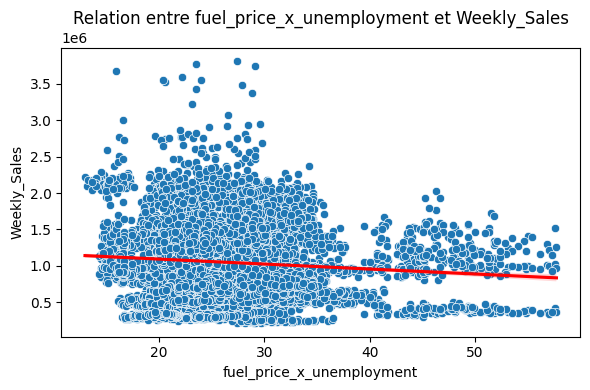

In [30]:
features_to_plot = ['Fuel_Price', 'Temperature_C', 'Unemployment', 'CPI', 
                    'total_holidays', 'fuel_price_x_unemployment']

for feature in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=data, x=feature, y='Weekly_Sales')
    sns.regplot(data=data, x=feature, y='Weekly_Sales', scatter=False, color='red')
    plt.title(f'Relation entre {feature} et Weekly_Sales')
    plt.tight_layout()
    plt.show()


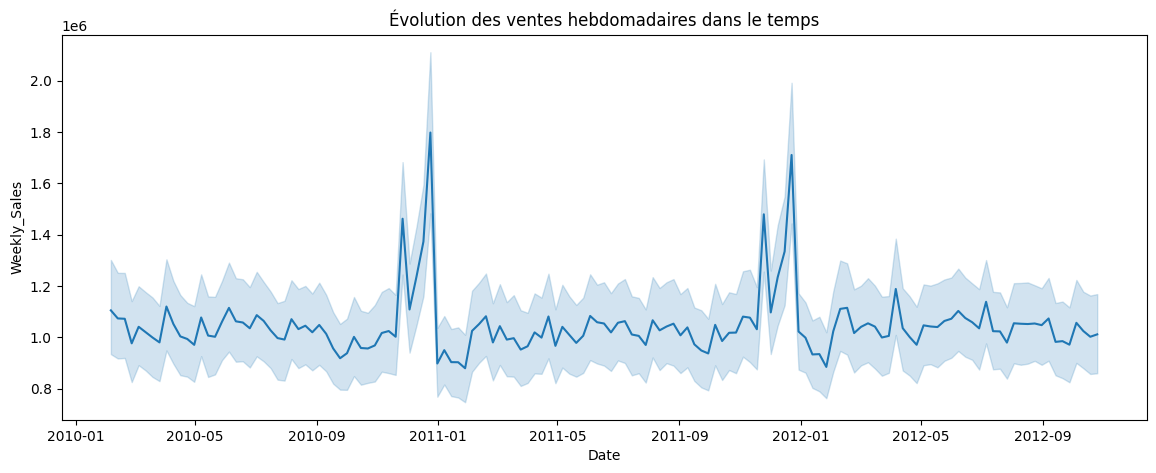

In [31]:
# Evolution des ventes dans le temps
plt.figure(figsize=(14, 5))
sns.lineplot(data=data.sort_values('Date'), x='Date', y='Weekly_Sales')
plt.title("Évolution des ventes hebdomadaires dans le temps")
plt.show()


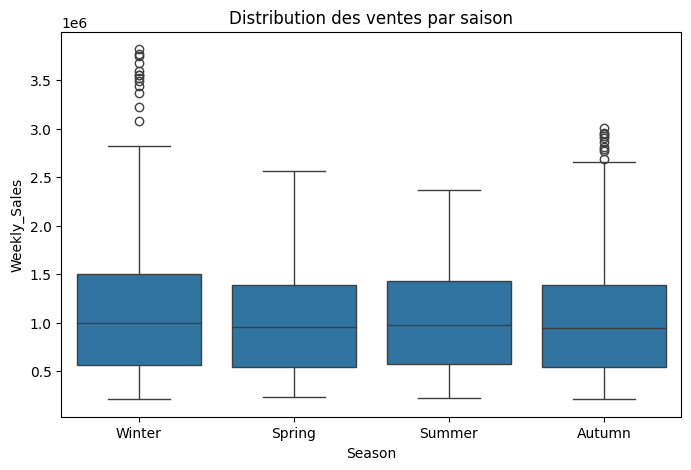

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Season', y='Weekly_Sales')
plt.title("Distribution des ventes par saison")
plt.show()


In [33]:
cor_target = corr['Weekly_Sales'].abs().sort_values(ascending=False)
print(cor_target)

Weekly_Sales                   1.000000
Weekly_Sales_rolling_mean_2    0.987852
Weekly_Sales_rolling_mean_4    0.976462
Weekly_Sales_rolling_std_4     0.439419
Weekly_Sales_rolling_std_2     0.382691
Store                          0.335332
Weekly_Sales_pct_change        0.155330
Weekly_Sales_diff              0.152241
cpi_x_unemployment             0.132527
Unemployment                   0.106176
fuel_price_x_unemployment      0.089673
Month                          0.076143
week_of_year                   0.074211
CPI                            0.072634
Christmas_flag                 0.067926
Temperature_C                  0.063810
Temperature                    0.063810
quarter                        0.063363
total_holidays                 0.059810
Thanksgiving_flag              0.055761
Season_encode                  0.040171
holiday_x_fuel_price           0.038318
Holiday_Flag                   0.036891
is_quarter_end                 0.027198
is_month_end                   0.024984


In [37]:
data["CPI"].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
6430    False
6431    False
6432    False
6433    False
6434    False
Name: CPI, Length: 6435, dtype: bool

In [39]:
for col in data.columns:
    if data[col].isnull().mean() != 0:
        print(col)

Weekly_Sales_rolling_std_2
Weekly_Sales_rolling_std_4
Weekly_Sales_pct_change
Weekly_Sales_diff


In [126]:
data = data.fillna(0)

In [127]:
data.isnull().mean()

Store                          0.0
Date                           0.0
Weekly_Sales                   0.0
Holiday_Flag                   0.0
Temperature                    0.0
Fuel_Price                     0.0
CPI                            0.0
Unemployment                   0.0
Month                          0.0
Year                           0.0
Day                            0.0
Season                         0.0
day_of_week                    0.0
week_of_year                   0.0
quarter                        0.0
is_month_start                 0.0
is_month_end                   0.0
is_quarter_start               0.0
is_quarter_end                 0.0
Weekly_Sales_rolling_mean_2    0.0
Weekly_Sales_rolling_std_2     0.0
Weekly_Sales_rolling_mean_4    0.0
Weekly_Sales_rolling_std_4     0.0
Weekly_Sales_pct_change        0.0
Weekly_Sales_diff              0.0
Temperature_C                  0.0
Season_encode                  0.0
fuel_price_x_unemployment      0.0
cpi_x_unemployment  

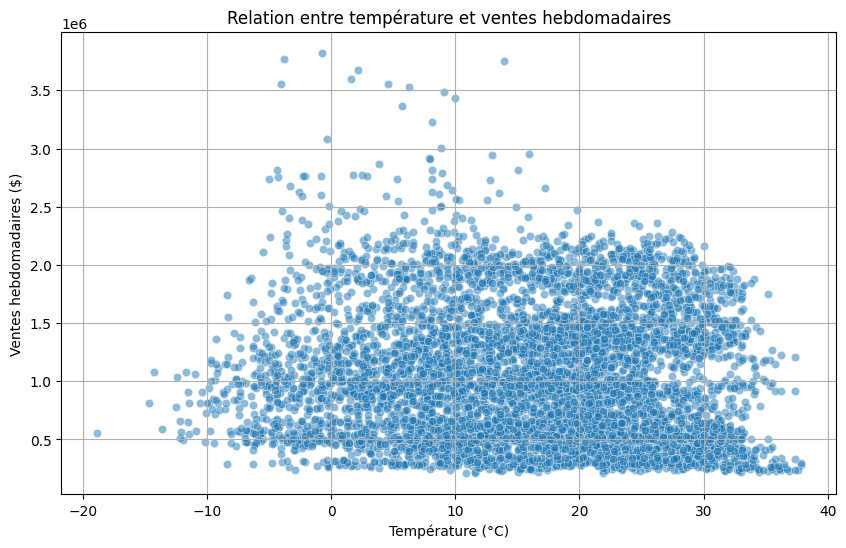

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x="Temperature_C", y="Weekly_Sales", alpha=0.5)
plt.title("Relation entre température et ventes hebdomadaires")
plt.xlabel("Température (°C)")
plt.ylabel("Ventes hebdomadaires ($)")
plt.grid(True)
plt.show()


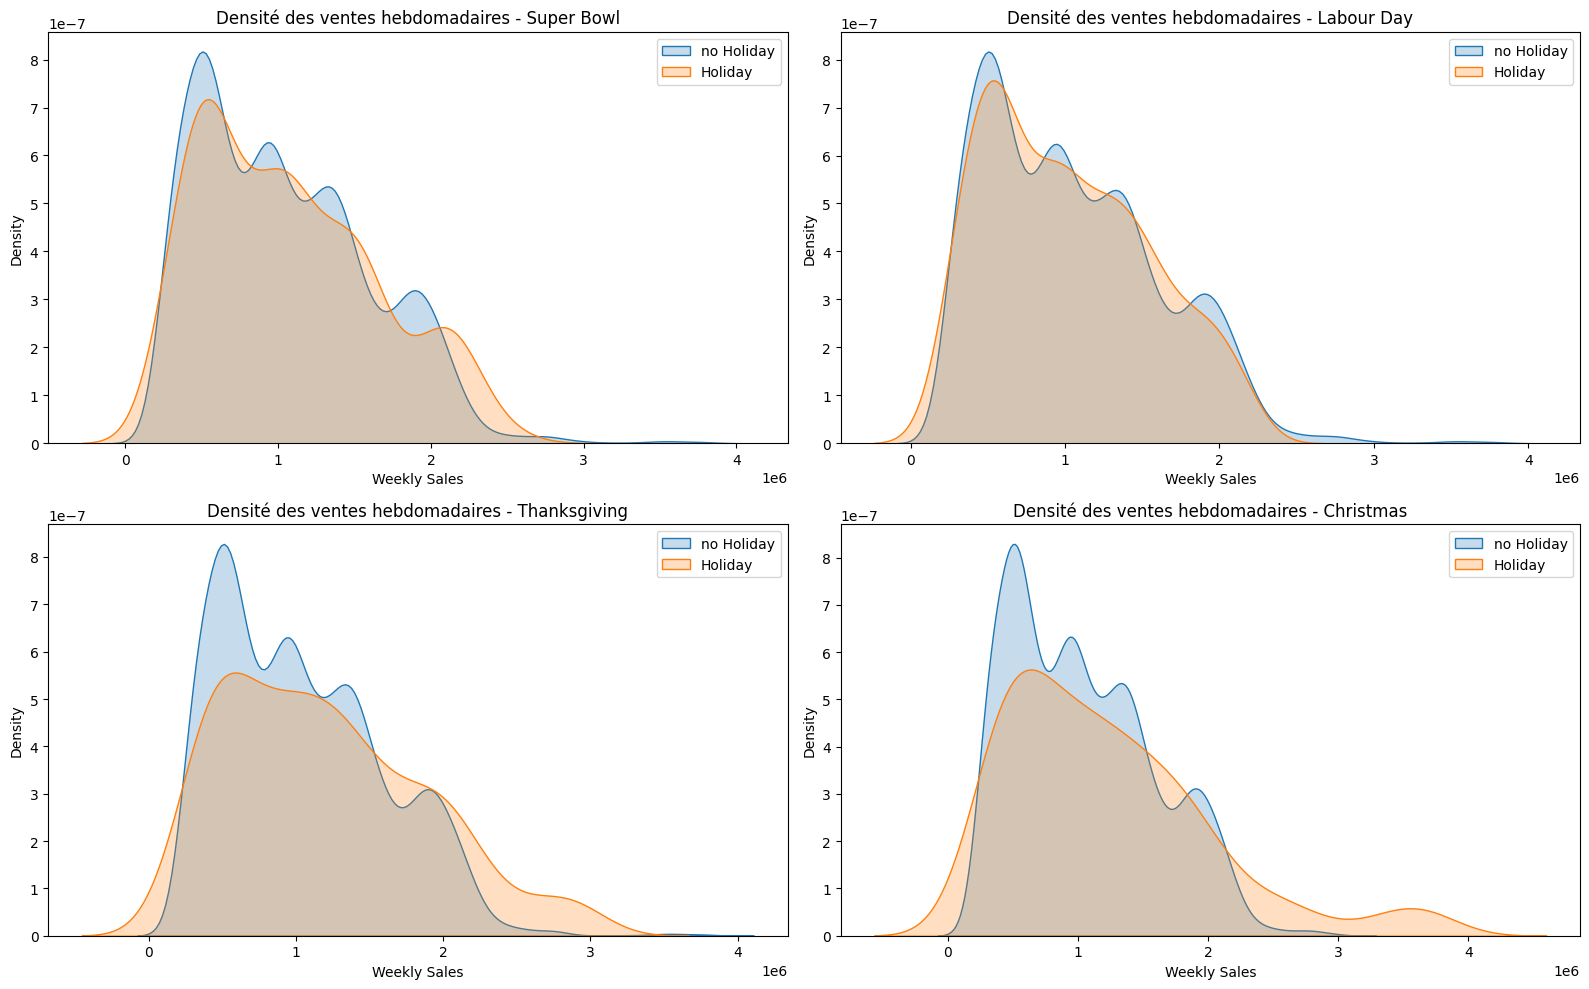

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

holiday_flags = ['Super_Bowl_flag', 'Labour_Day_flag', 'Thanksgiving_flag', 'Christmas_flag']

plt.figure(figsize=(16, 10))

for i, event in enumerate(holiday_flags, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data=data[data[event] == 0], x="Weekly_Sales", label='no Holiday', fill=True)
    sns.kdeplot(data=data[data[event] == 1], x="Weekly_Sales", label='Holiday', fill=True)
    plt.title(f"Densité des ventes hebdomadaires - {event.replace('_flag','').replace('_',' ')}")
    plt.xlabel("Weekly Sales")
    plt.legend()

plt.tight_layout()
plt.show()


Stores sélectionnés : [45 31 15 16 24]


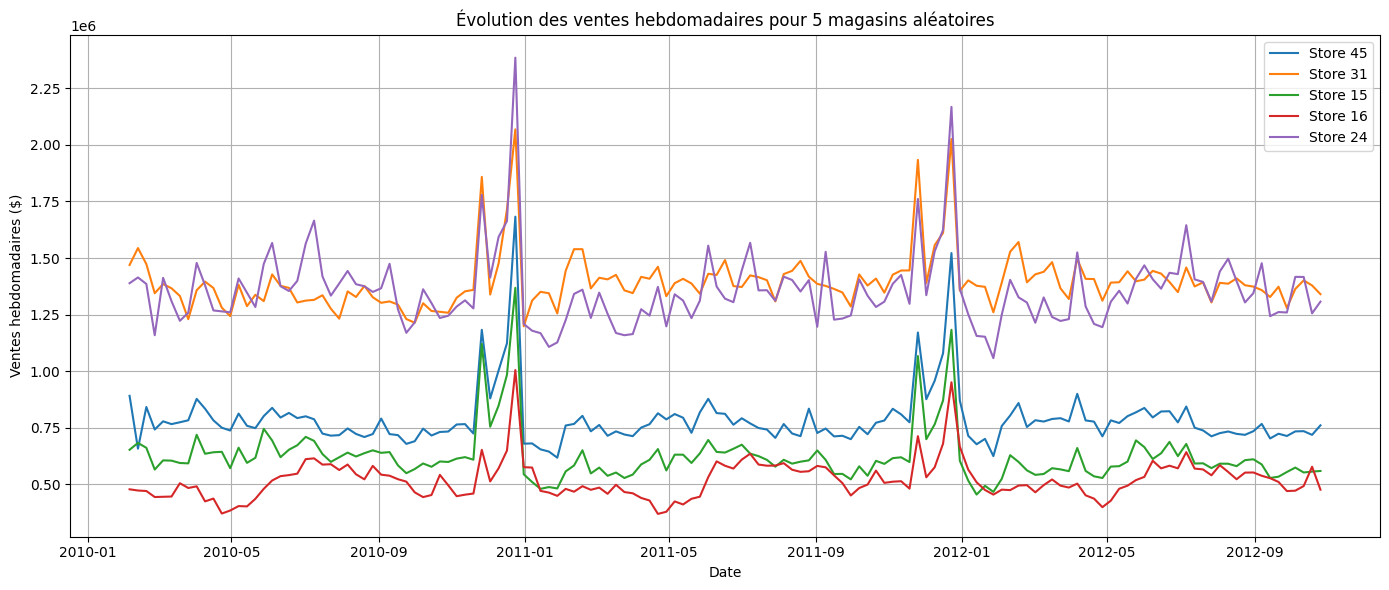

In [130]:
import numpy as np 
random_stores = np.random.choice(data['Store'].unique(), size=5, replace=False)
print("Stores sélectionnés :", random_stores)

plt.figure(figsize=(14, 6))

for store in random_stores:
    store_data = data[data['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales'], label=f'Store {store}')

plt.title("Évolution des ventes hebdomadaires pour 5 magasins aléatoires")
plt.xlabel("Date")
plt.ylabel("Ventes hebdomadaires ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


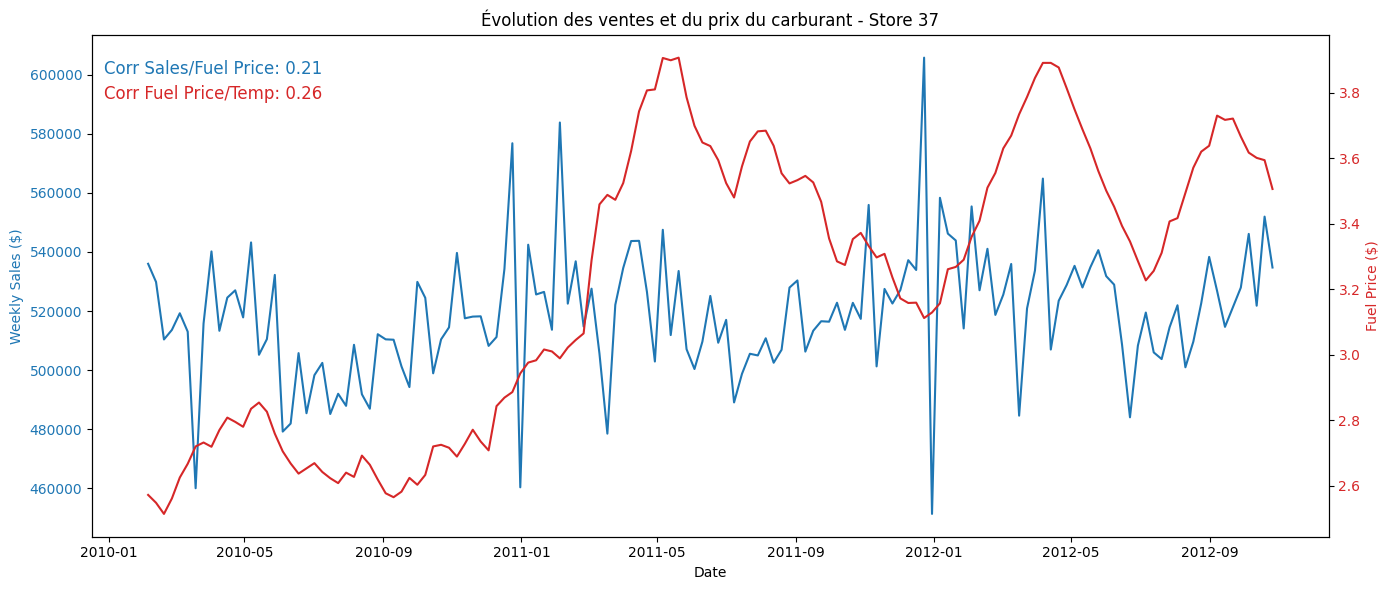

In [131]:
import random
import matplotlib.pyplot as plt

store_id = random.randint(1, len(data['Store'].unique()))
store_data = data[data['Store'] == store_id].sort_values('Date')

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(store_data['Date'], store_data['Weekly_Sales'], color='tab:blue', label='Weekly Sales')
ax1.set_xlabel('Date')
ax1.set_ylabel('Weekly Sales ($)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(store_data['Date'], store_data['Fuel_Price'], color='tab:red', label='Fuel Price')
ax2.set_ylabel('Fuel Price ($)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

corr = store_data[["Weekly_Sales","Fuel_Price"]].corr().iloc[0,1]
corr2 = store_data[["Fuel_Price","Temperature_C"]].corr().iloc[0,1]

ax1.text(0.01, 0.95, f"Corr Sales/Fuel Price: {corr:.2f}", transform=ax1.transAxes,
         fontsize=12, verticalalignment='top', color='tab:blue')
ax1.text(0.01, 0.90, f"Corr Fuel Price/Temp: {corr2:.2f}", transform=ax1.transAxes,
         fontsize=12, verticalalignment='top', color='tab:red')

plt.title(f"Évolution des ventes et du prix du carburant - Store {store_id}")
fig.tight_layout()
plt.show()


In [133]:
data = data.drop(columns=["Temperature"])

In [134]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Fuel_Price,CPI,Unemployment,Month,Year,Day,...,fuel_price_x_unemployment,cpi_x_unemployment,temp_x_season,Super_Bowl_flag,Labour_Day_flag,Thanksgiving_flag,Christmas_flag,holiday_x_fuel_price,holiday_x_temperature,total_holidays
0,1,2010-02-05,1643690.90,0.0,2.572,211.096358,8.106,2,2010,5,...,20.848632,1711.147080,17.183333,1,0,0,0,0.000,0.000000,1
1,1,2010-02-12,1641957.44,1.0,2.548,211.242170,8.106,2,2010,12,...,20.654088,1712.329028,10.850000,1,0,0,0,2.548,3.616667,1
2,1,2010-02-19,1611968.17,0.0,2.514,211.289143,8.106,2,2010,19,...,20.378484,1712.709792,13.216667,1,0,0,0,0.000,0.000000,1
3,1,2010-02-26,1409727.59,0.0,2.561,211.319643,8.106,2,2010,26,...,20.759466,1712.957025,24.383333,0,0,0,0,0.000,0.000000,0
4,1,2010-03-05,1554806.68,0.0,2.625,211.350143,8.106,3,2010,5,...,21.278250,1713.204258,8.055556,0,0,0,0,0.000,0.000000,0


In [150]:
features = [
    'Holiday_Flag', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year', 'Day',
    'fuel_price_x_unemployment', 'cpi_x_unemployment', 'temp_x_season',
    'Super_Bowl_flag', 'Labour_Day_flag', 'Thanksgiving_flag', 'Christmas_flag',
    'holiday_x_fuel_price', 'holiday_x_temperature', 'total_holidays',
    'Weekly_Sales_rolling_mean_2', 'Weekly_Sales_rolling_std_2',
    'Weekly_Sales_rolling_mean_4', 'Weekly_Sales_rolling_std_4',
    'Weekly_Sales_pct_change', 'Weekly_Sales_diff'
]


In [173]:
from sklearn.model_selection import train_test_split

df_store1 = data[data['Store'] == 1].copy()
df_store1 = df_store1.dropna()  

#out of time
test_start = '2012-09-01'
test_end = '2012-10-30'

sept_oct_2012_data = df_store1[(df_store1['Date'] >= test_start) & (df_store1['Date'] <= test_end)]

data_wo_sept_oct2012 = df_store1[(df_store1['Date'] < test_start) | (df_store1['Date'] > test_end)]

X = data_wo_sept_oct2012[features]
y = data_wo_sept_oct2012['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) 


In [174]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [175]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_test = model.predict(X_test)
print(f"Performance sur test set hors septembre octobre 2012 :")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_test):.3f}")

Performance sur test set hors septembre octobre 2012 :
RMSE : 32491.76
R2 : 0.888



Performance prédiction sur septembre octobre 2012 (exclu du training) :
RMSE : 21844.16
R2 : 0.921


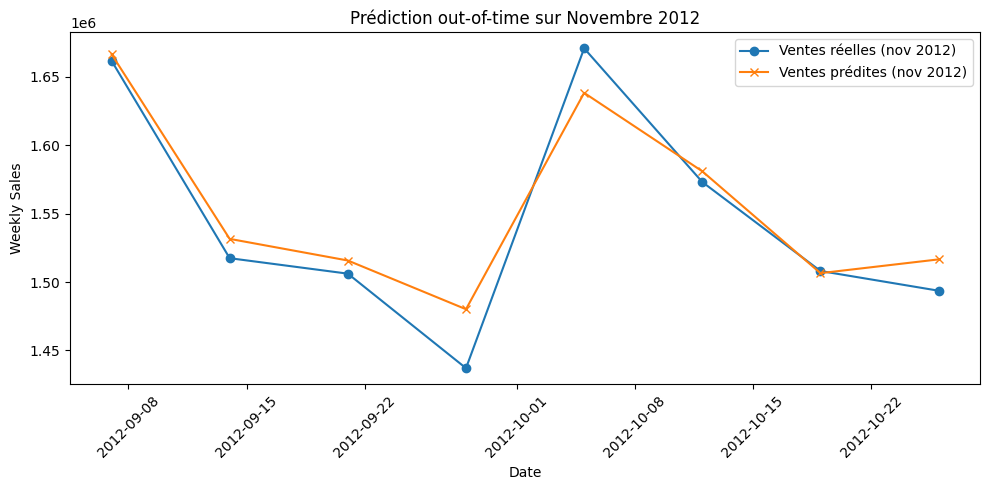

In [177]:
X_sept_oct_2012 = sept_oct_2012_data[features]
y_sept_oct_2012_true = sept_oct_2012_data['Weekly_Sales']

y_sept_oct_2012_pred = model.predict(X_sept_oct_2012)

print(f"\nPerformance prédiction sur septembre octobre 2012 (exclu du training) :")
print(f"RMSE : {np.sqrt(mean_squared_error(y_sept_oct_2012_true, y_sept_oct_2012_pred)):.2f}")
print(f"R2 : {r2_score(y_sept_oct_2012_true, y_sept_oct_2012_pred):.3f}")

plt.figure(figsize=(10,5))
plt.plot(sept_oct_2012_data['Date'], y_sept_oct_2012_true, label='Ventes réelles (nov 2012)', marker='o')
plt.plot(sept_oct_2012_data['Date'], y_sept_oct_2012_pred, label='Ventes prédites (nov 2012)', marker='x')
plt.title('Prédiction out-of-time sur Novembre 2012')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()